In [3]:
import os
os.chdir('/Users/angelinagupta/Desktop/sem 6/biomedical-nlp-project-beta')

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xml.etree.ElementTree as ET
import urllib.request
import zipfile
import io
import os


## Task 1: NCBI Disease Dataset (NER)
First, we load the dataset from HuggingFace and explore the token and label formats.

In [5]:
# Create data folder locally or in Drive
os.makedirs('data', exist_ok=True)

# Load the NCBI Disease dataset from HuggingFace parquet
PARQUET_BASE = "hf://datasets/ncbi_disease@refs/convert/parquet/ncbi_disease"
df_train = pd.read_parquet(f"{PARQUET_BASE}/train/0000.parquet")
df_val = pd.read_parquet(f"{PARQUET_BASE}/validation/0000.parquet")
df_test = pd.read_parquet(f"{PARQUET_BASE}/test/0000.parquet")

print("NCBI Disease Dataset Sizes:")
print(f"Train sentences: {len(df_train)}")
print(f"Validation sentences: {len(df_val)}")
print(f"Test sentences: {len(df_test)}")


NCBI Disease Dataset Sizes:
Train sentences: 5433
Validation sentences: 924
Test sentences: 941


In [6]:
label_map = {0: 'O', 1: 'B-Disease', 2: 'I-Disease'}

def format_tokens(row):
    tokens = row['tokens']
    tags = row['ner_tags']
    # Handle raw tags whether they are integers or strings
    if len(tags) > 0 and isinstance(tags[0], (int, np.integer)):
        tags = [label_map.get(t, 'O') for t in tags]
    return list(zip(tokens, tags))

print("Sample Sentences with BIO Tags (Train):\n")
for i in range(5):
    sample = format_tokens(df_train.iloc[i])
    formatted = " ".join([f"{word}[{tag}]" for word, tag in sample])
    print(f"Sample {i+1}:")
    print(formatted)
    print("-" * 80)


Sample Sentences with BIO Tags (Train):

Sample 1:
Identification[O] of[O] APC2[O] ,[O] a[O] homologue[O] of[O] the[O] adenomatous[B-Disease] polyposis[I-Disease] coli[I-Disease] tumour[I-Disease] suppressor[O] .[O]
--------------------------------------------------------------------------------
Sample 2:
The[O] adenomatous[B-Disease] polyposis[I-Disease] coli[I-Disease] ([I-Disease] APC[I-Disease] )[I-Disease] tumour[I-Disease] -[O] suppressor[O] protein[O] controls[O] the[O] Wnt[O] signalling[O] pathway[O] by[O] forming[O] a[O] complex[O] with[O] glycogen[O] synthase[O] kinase[O] 3beta[O] ([O] GSK[O] -[O] 3beta[O] )[O] ,[O] axin[O] /[O] conductin[O] and[O] betacatenin[O] .[O]
--------------------------------------------------------------------------------
Sample 3:
Complex[O] formation[O] induces[O] the[O] rapid[O] degradation[O] of[O] betacatenin[O] .[O]
--------------------------------------------------------------------------------
Sample 4:
In[O] colon[B-Disease] carcinoma[I-Dise

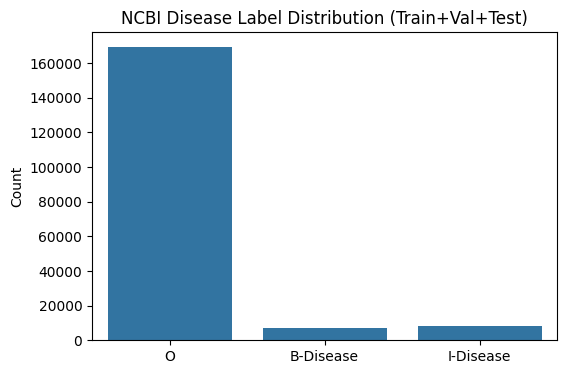

In [7]:
# Evaluate label distribution across entire dataset
all_tags = []
for tags in df_train['ner_tags']:
    all_tags.extend(tags)
for tags in df_val['ner_tags']:
    all_tags.extend(tags)
for tags in df_test['ner_tags']:
    all_tags.extend(tags)

mapped_tags = [label_map.get(t, 'O') if isinstance(t, (int, np.integer)) else t for t in all_tags]

plt.figure(figsize=(6, 4))
sns.countplot(x=mapped_tags)
plt.title('NCBI Disease Label Distribution (Train+Val+Test)')
plt.ylabel('Count')
plt.show()


In [8]:
df_all = pd.concat([df_train, df_val, df_test])

df_all['sent_length'] = df_all['tokens'].apply(len)
print(f"Average sentence length: {df_all['sent_length'].mean():.2f} tokens")
print(f"Max sentence length: {df_all['sent_length'].max()} tokens")

entities = []
entity_lengths = []
for idx, row in df_all.iterrows():
    tokens = row['tokens']
    tags = row['ner_tags']
    
    current_entity = []
    
    for token, tag in zip(tokens, tags):
        if tag == 1 or tag == 'B-Disease': 
            if current_entity:
                entities.append(" ".join(current_entity))
                entity_lengths.append(len(current_entity))
            current_entity = [token]
        elif tag == 2 or tag == 'I-Disease': 
            if current_entity:
                current_entity.append(token)
        else:
            if current_entity:
                entities.append(" ".join(current_entity))
                entity_lengths.append(len(current_entity))
                current_entity = []
    if current_entity:
        entities.append(" ".join(current_entity))
        entity_lengths.append(len(current_entity))

unique_entities = set(entities)
print(f"\nNumber of unique disease entities: {len(unique_entities)}")

from collections import Counter
entity_counts = Counter(entities)
print("\nTop 20 most common diseases:")
for ent, count in entity_counts.most_common(20):
    print(f"- {ent}: {count}")


Average sentence length: 25.29 tokens
Max sentence length: 123 tokens

Number of unique disease entities: 2134

Top 20 most common diseases:
- DM: 176
- APC: 119
- DMD: 115
- ALD: 98
- PWS: 90
- breast cancer: 87
- A - T: 78
- HD: 77
- myotonic dystrophy: 75
- WAS: 74
- VHL: 66
- aniridia: 66
- tumor: 64
- cancer: 62
- G6PD deficiency: 60
- PKU: 56
- FAP: 54
- ataxia - telangiectasia: 47
- Duchenne muscular dystrophy: 47
- ovarian cancer: 45


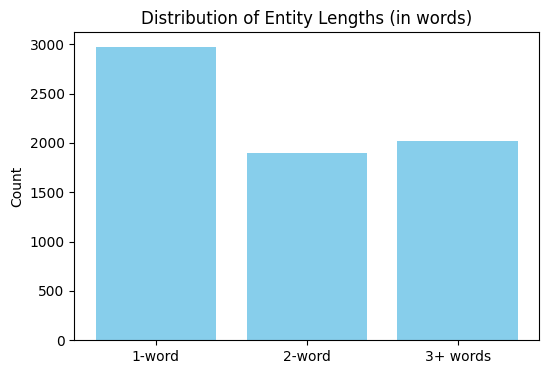

In [9]:
lengths_series = pd.Series(entity_lengths).value_counts().sort_index()
grouped_lengths = {
    '1-word': lengths_series.get(1, 0),
    '2-word': lengths_series.get(2, 0),
    '3+ words': lengths_series[lengths_series.index >= 3].sum()
}

plt.figure(figsize=(6, 4))
plt.bar(grouped_lengths.keys(), grouped_lengths.values(), color='skyblue')
plt.title('Distribution of Entity Lengths (in words)')
plt.ylabel('Count')
plt.show()


### NCBI Disease Visualizations: Implications
- **Label Imbalance**: We observe a massive skew towards the `O` class, which dominates the tokens. Recognizing `B-Disease` and `I-Disease` without falling into a local minimum where the model blindly predicts `O`, will be a core challenge.
- **Entity Complexity**: The multi-word distribution chart highlights many diseases span multiple tokens (e.g., 'ovarian cancer', 'Duchenne muscular dystrophy'). Therefore, our model must understand phrase-level context rather than treating tokens in isolation.

## Task 2: DDI Corpus (Relation Extraction)
Next, we parse the DDI XML dataset to extract drug-drug interaction pairs.

In [12]:
# Download DDI Corpus
url = "https://github.com/isegura/DDICorpus/archive/refs/heads/master.zip"
zip_path = "data/DDICorpus.zip"

if not os.path.exists(zip_path):
    print("Downloading DDI...\n")
    urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data/")

train_path = 'data/ddi_corpus/Train/DrugBank/'
test_path = 'data/ddi_corpus/Test/Test for DDI Extraction task/DrugBank/'

def parse_ddi(path):
    records = []
    for filename in os.listdir(path):
        if not filename.endswith('.xml'):
            continue
        filepath = os.path.join(path, filename)
        tree = ET.parse(filepath)
        root = tree.getroot()
        
        for sentence in root.findall('.//sentence'):
            sent_text = sentence.get('text', '')
            
            entities = {}
            for entity in sentence.findall('entity'):
                entities[entity.get('id')] = entity.get('text')
            
            for pair in sentence.findall('pair'):
                e1_id = pair.get('e1')
                e2_id = pair.get('e2')
                
                ddi = pair.get('ddi') == 'true'
                rel_type = pair.get('type') if ddi else 'no-relation'
                
                records.append({
                    'sentence': sent_text,
                    'drug1': entities.get(e1_id, ''),
                    'drug2': entities.get(e2_id, ''),
                    'relation': rel_type
                })
    return pd.DataFrame(records)

df_ddi_train = parse_ddi(train_path)
df_ddi_test = parse_ddi(test_path)

print(f"DDI Train records: {len(df_ddi_train)}")
print(f"DDI Test records: {len(df_ddi_test)}\n")

print("Sample drug pairs and relation labels:")
display(df_ddi_train.head(5)[['drug1', 'drug2', 'relation']])


DDI Train records: 26005
DDI Test records: 5265

Sample drug pairs and relation labels:


,drug1,drug2,relation
0,calcium,EMCYT,mechanism
1,allopurinol,ampicillin,effect
2,allopurinol,ampicillin,no-relation
3,ampicillin,ampicillin,no-relation
4,ampicillin,allopurinol,effect


Text(0, 0.5, 'Count')

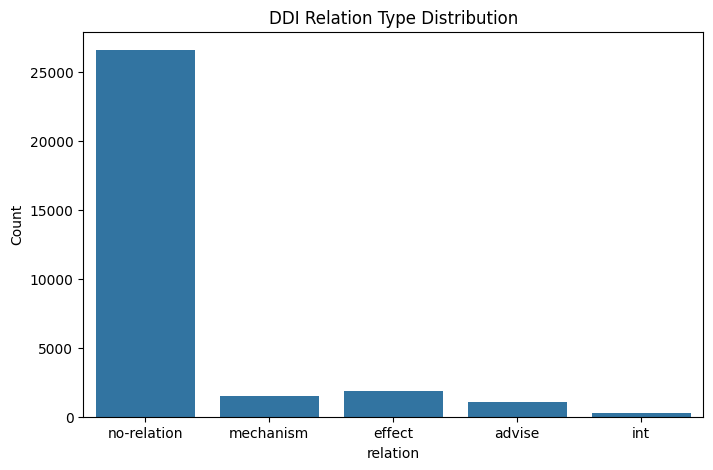

In [14]:
plt.figure(figsize=(8, 5))
combined = pd.concat([df_ddi_train, df_ddi_test]).reset_index(drop=True)
sns.countplot(data=combined, x='relation',
              order=['no-relation', 'mechanism', 'effect', 'advise', 'int'])
plt.title("DDI Relation Type Distribution")
plt.ylabel('Count')

### DDI Visualizations: Implications
- **Vast Class Imbalance (RE)**: `no-relation` heavily dwarfs the actual relations. In particular, `int` is extremely sparse. It emphasizes the need for class weighting, under-sampling of `no-relation` pairs, or macro-F1 evaluation bounds to track true interaction accuracy.
- **Context Challenges**: Since a pair spans arbitrarily in a sentence, capturing the linguistic context and properly masking entities to prevent the model from purely memorizing drug pairs rather than learning the mechanism, will be critical down the line.

In [15]:
# Save datasets
df_train.to_csv("data/ncbi_train.csv", index=False)
df_val.to_csv("data/ncbi_val.csv", index=False)
df_test.to_csv("data/ncbi_test.csv", index=False)

df_ddi_train.to_csv("data/ddi_train.csv", index=False)
df_ddi_test.to_csv("data/ddi_test.csv", index=False)

print("All datasets successfully exported to the 'data/' folder!\n")


All datasets successfully exported to the 'data/' folder!

